# CodiEsp - Sample Clinical Cases - Knowledge Graph

Data responses were generated from GPT-4o using a prompt template which included the clinical cases: ICD-10 diagnoses codes and the clinical notes.  Each ICD code along with the clinical notes was used to determine the relations type between the ICD-10 titles (Casual, Risk Factors, Associations, or no direct relationship)  

<hr style="height:1rem;">

## 1.0 Imports

In [1]:
import uuid
import numpy as np
import pandas as pd

import re
import json
import os
from pathlib import Path

import networkx as nx
import matplotlib.pyplot as plt

<hr style="height:1rem;">

## 2.0 Path Settings

In [2]:
NOTEBOOK_PATH = os.getcwd()
NOTEBOOK_DATA_PATH = os.path.join(
    NOTEBOOK_PATH,
    'data'
)
NOTEBOOK_EVALUATION_PATH = os.path.join(
    NOTEBOOK_PATH,
    'evaluation'
)
NOTEBOOK_RESULTS_PATH = os.path.join(
    NOTEBOOK_PATH,
    'results'
)
CLINICAL_CASE_PATH = Path.cwd().resolve().parents[0]
MODEL_PATH = Path.cwd().resolve().parents[1]
PARENT_NOTEBOOK_PATH = Path.cwd().resolve().parents[2]
SEARCH_PATH = os.path.join(
    PARENT_NOTEBOOK_PATH,
    'results'
)
DISSERTATION_PATH = Path.cwd().resolve().parents[3]
DISSERTATION_DATA_PATH = os.path.join(
    DISSERTATION_PATH,
    'data'
)
PROJECT_PATH = Path.cwd().resolve().parents[4]
PROJECT_DATA_PATH = os.path.join(
    PROJECT_PATH,
    'data'
)

print(NOTEBOOK_PATH)
print(NOTEBOOK_DATA_PATH)
print(NOTEBOOK_RESULTS_PATH)
print(NOTEBOOK_EVALUATION_PATH)
print(CLINICAL_CASE_PATH)
print(MODEL_PATH)
print(PARENT_NOTEBOOK_PATH)
print(SEARCH_PATH)
print(DISSERTATION_PATH)
print(DISSERTATION_DATA_PATH)
print(PROJECT_PATH)
print(PROJECT_DATA_PATH)

D:\ODU\03 - Dissertation Defense\003_dissertation\notebook\06_knowledge_graph
D:\ODU\03 - Dissertation Defense\003_dissertation\notebook\06_knowledge_graph\data
D:\ODU\03 - Dissertation Defense\003_dissertation\notebook\06_knowledge_graph\results
D:\ODU\03 - Dissertation Defense\003_dissertation\notebook\06_knowledge_graph\evaluation
D:\ODU\03 - Dissertation Defense\003_dissertation\notebook
D:\ODU\03 - Dissertation Defense\003_dissertation
D:\ODU\03 - Dissertation Defense
D:\ODU\03 - Dissertation Defense\results
D:\ODU
D:\ODU\data
D:\
D:\data


<hr style="height:1rem;">

## Read Data into DataFrame

In [3]:
# Sample JSON Data
clinical_case_1 = {
  "nodes": [
    {"id": "I10", "name": "Essential hypertension", "type": "Disease"},
    {"id": "E78.5", "name": "Hyperlipidemia, unspecified", "type": "Disease"},
    {"id": "I25.9", "name": "Chronic ischemic heart disease, unspecified", "type": "Disease"},
    {"id": "I21.19", "name": "STEMI involving other coronary artery of inferior wall", "type": "Disease"},
    {"id": "I25.2", "name": "Old myocardial infarction", "type": "Disease"},
    {"id": "I12.9", "name": "Hypertensive chronic kidney disease", "type": "Disease"},
    {"id": "N18.9", "name": "Chronic kidney disease, unspecified", "type": "Disease"},
    {"id": "Z99.2", "name": "Dependence on renal dialysis", "type": "Condition"},
    {"id": "M54.5", "name": "Low back pain", "type": "Symptom"},
    {"id": "M46.40", "name": "Discitis, unspecified", "type": "Disease"},
    {"id": "B95.61", "name": "Methicillin susceptible Staphylococcus aureus infection", "type": "Disease"},
    {"id": "R50.9", "name": "Fever, unspecified", "type": "Symptom"},
    {"id": "R52", "name": "Pain, unspecified", "type": "Symptom"}
  ],
  "edges": [
    {
      "source": "I10",
      "target": "I12.9",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "History of arterial hypertension leading to hypertensive chronic kidney disease."
    },
    {
      "source": "I12.9",
      "target": "N18.9",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "Chronic renal failure possibly secondary to nephroangiopathy."
    },
    {
      "source": "N18.9",
      "target": "Z99.2",
      "relationship": "COMPLICATES",
      "confidence": "High",
      "supporting_text": "Patient has been on hemodialysis since December 2010."
    },
    {
      "source": "B95.61",
      "target": "M46.40",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "Positive microbiological results for S. aureus led to diagnosis of discitis."
    },
    {
      "source": "M46.40",
      "target": "M54.5",
      "relationship": "ASSOCIATED_WITH",
      "confidence": "Medium",
      "supporting_text": "Patient reported postural low back pain, later diagnosed with discitis."
    },
    {
      "source": "M46.40",
      "target": "R52",
      "relationship": "ASSOCIATED_WITH",
      "confidence": "Medium",
      "supporting_text": "Patient experienced intense low back pain due to discitis."
    },
    {
      "source": "M46.40",
      "target": "R50.9",
      "relationship": "ASSOCIATED_WITH",
      "confidence": "Medium",
      "supporting_text": "Fever reported after catheter removal, later linked to discitis."
    },
    {
      "source": "I21.19",
      "target": "I25.9",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "History of myocardial infarction leading to ischemic heart disease."
    },
    {
      "source": "I25.9",
      "target": "I25.2",
      "relationship": "COMPLICATES",
      "confidence": "High",
      "supporting_text": "Chronic ischemic heart disease related to prior myocardial infarction."
    }
  ]
}

In [4]:
clinical_case_2 = {
  "nodes": [
    {"id": "R20.1", "name": "Hypoesthesia of skin", "type": "Disease"},
    {"id": "R20.2", "name": "Paresthesia of skin", "type": "Disease"},
    {"id": "R52", "name": "Pain, unspecified", "type": "Symptom"},
    {"id": "R60.9", "name": "Edema, unspecified", "type": "Symptom"},
    {"id": "M79.603", "name": "Pain in arm, unspecified", "type": "Symptom"},
    {"id": "G62.9", "name": "Polyneuropathy, unspecified", "type": "Disease"},
    {"id": "G56.20", "name": "Lesion of ulnar nerve, unspecified upper limb", "type": "Disease"},
    {"id": "M25.439", "name": "Effusion, unspecified wrist", "type": "Symptom"}
  ],
  "edges": [
    {
      "source": "G56.20",
      "target": "R20.2",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "The neurophysiological study showed a compressive neuropathy of the ulnar nerve in the Guyon channel."
    },
    {
      "source": "G56.20",
      "target": "R52",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "A 34-year-old male presented with a two-week history of pain with paresthesia in the ulnar edge of his hand."
    },
    {
      "source": "G56.20",
      "target": "M79.603",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "Pain in the arm was reported due to ulnar nerve compression."
    },
    {
      "source": "M25.439",
      "target": "R52",
      "relationship": "ASSOCIATED_WITH",
      "confidence": "Medium",
      "supporting_text": "The patient had persistent pain and effusion in the wrist."
    },
    {
      "source": "R60.9",
      "target": "G56.20",
      "relationship": "COMPLICATES",
      "confidence": "Medium",
      "supporting_text": "Diffuse swelling in the volar face of the ulnar area of the wrist and hand was observed, complicating ulnar nerve compression."
    },
    {
      "source": "G56.20",
      "target": "R20.1",
      "relationship": "CAUSES",
      "confidence": "High",
      "supporting_text": "Four months after surgery, the patient was free of symptoms except for hypoesthesia of the fourth finger."
    }
  ]
}

In [5]:
json_list = [clinical_case_1, clinical_case_2]

In [6]:
def merge_jsons(json_list):
    merged = {"nodes": [], "edges": []}
    
    node_ids = set()
    edge_set = set()
    
    for json_data in json_list:
        for node in json_data.get("nodes", []):
            if node["id"] not in node_ids:
                merged["nodes"].append(node)
                node_ids.add(node["id"])
        
        for edge in json_data.get("edges", []):
            edge_tuple = (edge["source"], edge["target"], edge["relationship"])
            if edge_tuple not in edge_set:
                merged["edges"].append(edge)
                edge_set.add(edge_tuple)

    return merged

In [7]:
data = merge_jsons(json_list)

<hr style="height:1rem;">

## Build Knowledge Graph

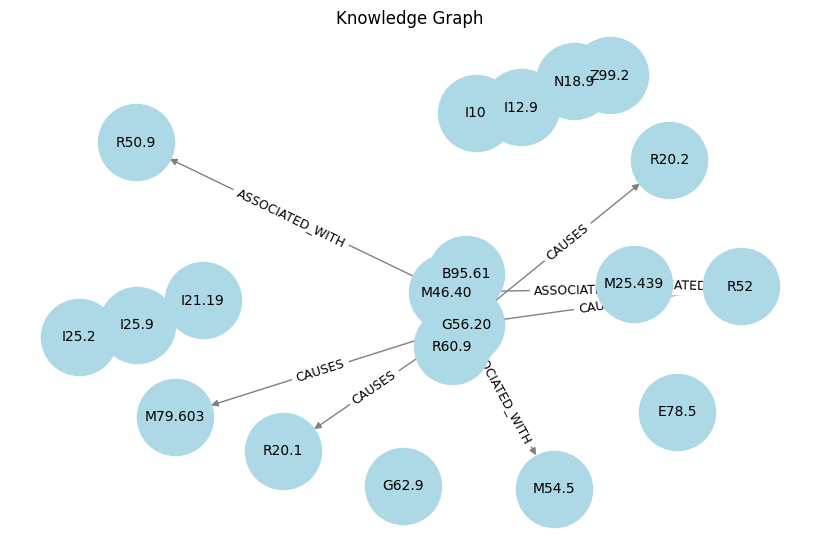

In [8]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes
for node in data["nodes"]:
    G.add_node(node["id"], label=node["name"], type=node["type"])

# Add edges
for edge in data["edges"]:
    G.add_edge(edge["source"], edge["target"], 
               relationship=edge["relationship"], 
               confidence=edge["confidence"],
               text=edge["supporting_text"])

# Draw the Graph
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G)  # Layout for visualization
labels = nx.get_edge_attributes(G, 'relationship')

nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=3000, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9)
plt.title("Knowledge Graph")
plt.show()

In [9]:
from pyvis.network import Network

# Create a Pyvis network
#net = Network(notebook=True, height="600px", width="100%")
net = Network(notebook=True, height="600px", width="100%", directed=True)

# Add nodes
for node in data["nodes"]:
    label_name = str(node["id"]) + " (" + node["name"] + ")"
    #net.add_node(node["id"], label=node["name"], title=node["type"], color="lightblue")
    net.add_node(node["id"], label=label_name, title=node["type"], color="lightblue")

# Add edges
for edge in data["edges"]:
    net.add_edge(edge["source"], edge["target"], 
                 title=edge["relationship"] + " (" + edge["confidence"] + ")")

# Save and display
net.show("knowledge_graph.html")

knowledge_graph.html
